<a href="https://colab.research.google.com/github/Bubukisapisa/ML_midterm_project/blob/main/%22Mid_term_Project_EDA_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в барнку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
from sklearn import preprocessing
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
import time
import matplotlib.pyplot as plt
import seaborn as sns
from compute_column_stats import compute_column_stats
from categorical_stats_compare import uni_cat_target_compare as uctc
from plot_conversion import plot_conversion

In [ ]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.shape

(41188, 21)

Перевіряю чи є колонки з пустими значеннями

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

Пустих значень нема, отже заповнювати пропуски непотрібно

Перевіряю на дисбаланс цільове значення

In [ ]:
df['y'].value_counts()

,count
y,
no,36548
yes,4640


Дисбаланс суттєвий тому як цільову метрику використовуватиму F1 score.
accuracy не підходить бо передбачаючи завжди 0 можна отримати точність 89%
ROCAUC теж може давати хибне позитивне значення при такому дисбалансі.

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
df['y'].unique()

array(['no', 'yes'], dtype=object)

In [ ]:
df['y'] = df['y'].apply(lambda x: 0 if x == 'no' else 1)
df['y'].value_counts()

,count
y,
0,36548
1,4640


In [ ]:
numeric_cols = df.select_dtypes(include=['int', 'float']).columns
numeric_cols

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [ ]:
cat_cols = df.columns.difference(numeric_cols)
cat_cols

Index(['contact', 'day_of_week', 'default', 'education', 'housing', 'job',
       'loan', 'marital', 'month', 'poutcome'],
      dtype='object')

In [ ]:
df[numeric_cols].corr()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725,0.030399
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703,0.405274
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095,-0.066357
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605,-0.324914
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333,0.230181
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970,-0.298334
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034,-0.136211
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513,0.054878
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154,-0.307771
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000,-0.354678


Всі числові фічі мають сильну кореляцію з цільовою змінною окрім віку

###Аналіз числових фіч

Аналіз age

In [ ]:
df['age'].describe(percentiles=[0.25, 0.5, 0.75, 0.99, 0.99999])

,age
count,41188.00000
mean,40.02406
std,10.42125
min,17.00000
25%,32.00000
50%,38.00000
75%,47.00000
99%,71.00000
99.999%,98.00000
max,98.00000


In [ ]:
df[df.age >=98]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
38452,98,retired,married,basic.4y,unknown,yes,no,cellular,oct,fri,...,1,2,2,success,-3.4,92.431,-26.9,0.73,5017.5,1
38455,98,retired,married,basic.4y,unknown,yes,no,cellular,oct,fri,...,2,999,0,nonexistent,-3.4,92.431,-26.9,0.73,5017.5,1


In [ ]:
df[df.age <= 17]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
37140,17,student,single,unknown,no,yes,no,cellular,aug,wed,...,3,4,2,success,-2.9,92.201,-31.4,0.884,5076.2,0
37539,17,student,single,basic.9y,no,yes,no,cellular,aug,fri,...,2,999,2,failure,-2.9,92.201,-31.4,0.869,5076.2,0
37558,17,student,single,basic.9y,no,yes,no,cellular,aug,fri,...,3,4,2,success,-2.9,92.201,-31.4,0.869,5076.2,0
37579,17,student,single,basic.9y,no,unknown,unknown,cellular,aug,fri,...,2,999,1,failure,-2.9,92.201,-31.4,0.869,5076.2,1
38274,17,student,single,unknown,no,no,yes,cellular,oct,tue,...,1,2,2,success,-3.4,92.431,-26.9,0.742,5017.5,1


###Висновки щодо колонки age
Мінімальне значення віку 17 що імовірно логічно (хоча очікував 18). Решта - в межах 32-47 років тобто зрілі люди, непенсійного віку.
Також є викиди - люди віком 98 років, але, це можливо і таких лише двоє.
Викидати якісь дані не вбачаю доцільним.

In [ ]:
import warnings

def dist_box(dataset, column):
    with warnings.catch_warnings():
      warnings.simplefilter("ignore")

      plt.figure(figsize=(16,6))

      plt.subplot(1,2,1)
      sns.distplot(dataset[column], color = 'purple')
      pltname = 'Графік розподілу для ' + column
      plt.ticklabel_format(style='plain', axis='x')
      plt.title(pltname)

      plt.subplot(1,2,2)
      red_diamond = dict(markerfacecolor='r', marker='D')
      sns.boxplot(y = column, data = dataset, flierprops = red_diamond)
      pltname = 'Боксплот для ' + column
      plt.title(pltname)

      plt.show()

Колонка campaign

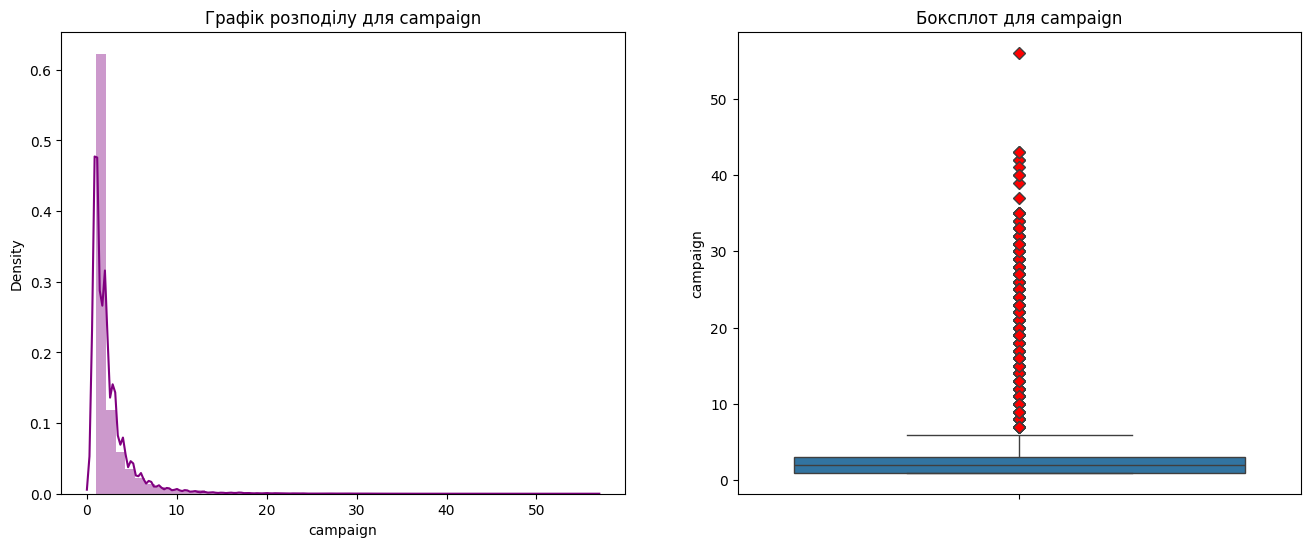

In [ ]:
dist_box(df, 'campaign')

In [ ]:
Q1_camp = df['campaign'].quantile(0.25)
Q3_camp = df['campaign'].quantile(0.75)
IQR_camp = Q3_camp - Q1_camp
median_camp = df['campaign'].median()
print(IQR_camp, Q1_camp, median_camp, Q3_camp)

2.0 1.0 2.0 3.0


In [ ]:
df['campaign'].mode()

,campaign
0,1


In [ ]:
Max_value_camp = (Q3_camp + 1.5 * IQR_camp)
Max_value_camp

np.float64(6.0)

In [ ]:
df[df.campaign > 50]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
4107,32,admin.,married,university.degree,unknown,unknown,unknown,telephone,may,mon,...,56,999,0,nonexistent,1.1,93.994,-36.4,4.858,5191.0,0


###Висновок до колонки campaign
75% клієнтів мали до 3 контактів, в межах IQR до 6 контактів, решта викиди. Але викиди не виглядають як аномалії і їх достатньо багато.

Розподіл сильно скошений вправо, необхідно зробити лог трансформацію.

###Колонка pdays

In [ ]:
compute_column_stats(df['pdays'])

{'column': 'pdays',
 'n_total': 41188,
 'n_missing': 0,
 'min': 0.0,
 'max': 999.0,
 'mean': 962.4755,
 'median': 999.0,
 'std': 186.9109,
 'q1': 999.0,
 'q3': 999.0,
 'iqr': 0.0,
 'iqr_lower_fence': 999.0,
 'iqr_upper_fence': 999.0,
 'n_iqr_outliers': 1515,
 'pct_iqr_outliers': 3.68,
 'n_zscore_outliers': 1515,
 'pct_zscore_outliers': 3.68,
 'skewness': np.float64(-4.9222),
 'kurtosis': np.float64(22.2295),
 'shapiro_p': 0.0,
 'is_normal': np.False_,
 'n_zeros': 15,
 'pct_zeros': 0.04,
 'n_sentinel_999': 39673,
 'pct_sentinel_999': 96.32,
 'n_unique': 27,
 'top5_values': '{999: 39673, 3: 439, 6: 412, 4: 118, 9: 64}'}

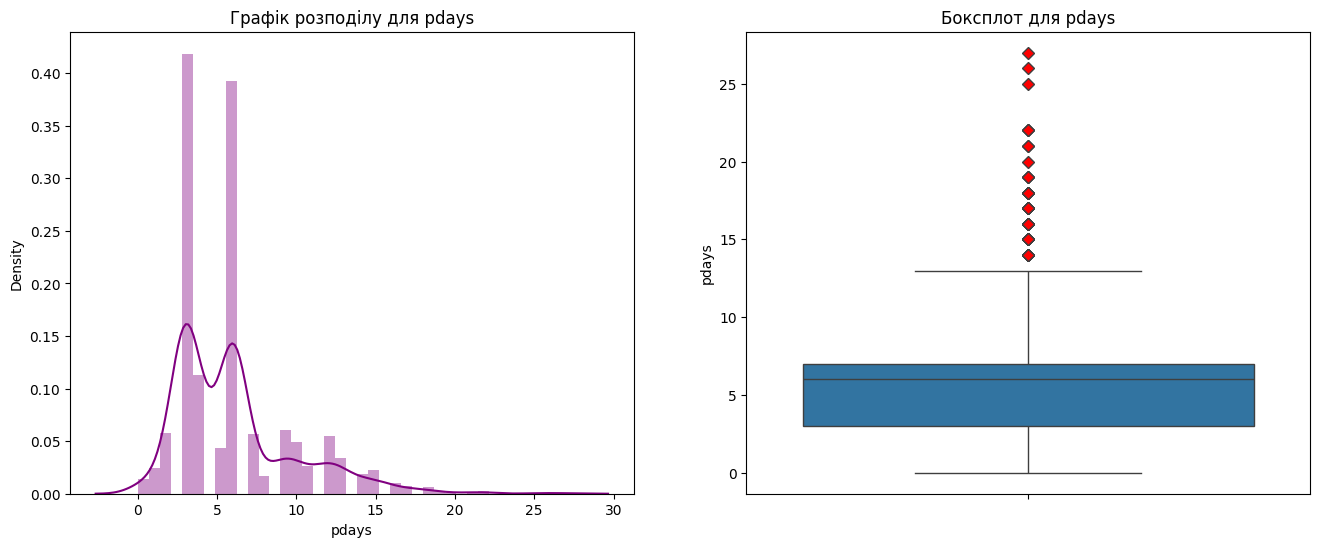

In [ ]:
dist_box(df[df['pdays'] < 999], 'pdays')

###Висоновки до колонки pdays

Реальні значення (0–27 днів) мають лише 1515 записів. Решта - штучний код 999 («клієнта не контактували раніше»).

Спробую створити нові фічі на базі цієї - бінарна was_contacted (1 якщо pdays ≠ 999), 2) числова pdays_real (значення лише де contacted = 1, інакше NaN).

#### Колонка previous

In [ ]:
compute_column_stats(df['previous'])

{'column': 'previous',
 'n_total': 41188,
 'n_missing': 0,
 'min': 0.0,
 'max': 7.0,
 'mean': 0.173,
 'median': 0.0,
 'std': 0.4949,
 'q1': 0.0,
 'q3': 0.0,
 'iqr': 0.0,
 'iqr_lower_fence': 0.0,
 'iqr_upper_fence': 0.0,
 'n_iqr_outliers': 5625,
 'pct_iqr_outliers': 13.66,
 'n_zscore_outliers': 1064,
 'pct_zscore_outliers': 2.58,
 'skewness': np.float64(3.832),
 'kurtosis': np.float64(20.1088),
 'shapiro_p': 0.0,
 'is_normal': np.False_,
 'n_zeros': 35563,
 'pct_zeros': 86.34,
 'n_sentinel_999': 0,
 'pct_sentinel_999': 0.0,
 'n_unique': 8,
 'top5_values': '{0: 35563, 1: 4561, 2: 754, 3: 216, 4: 70}'}

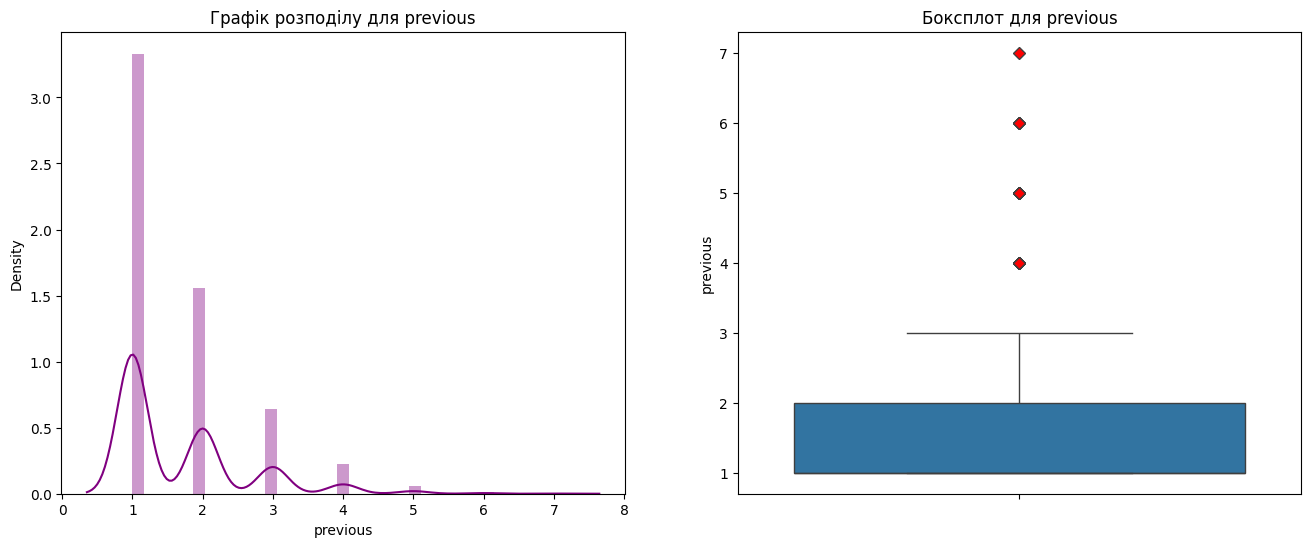

In [ ]:
dist_box(df[df['pdays'] < 999], 'previous')

###Висновок до колонки previous

Більшість значень 0, тобто відсутність попередньої комунікації.
Так як значення колонки не є неперервними (дискретні?) то краще переробити в категорії.

Для категоріальних даних перевіряю к-ть унікальних значень

In [ ]:
from enum import unique
df[cat_cols].nunique()

,0
contact,2
day_of_week,5
default,3
education,8
housing,3
job,12
loan,3
marital,4
month,10
poutcome,3


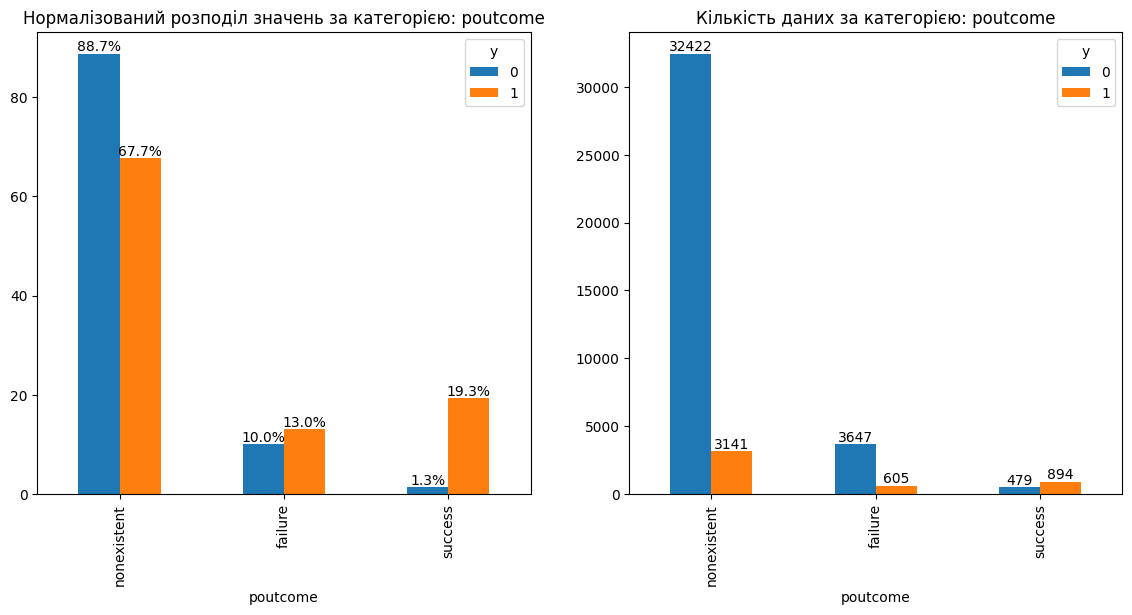

In [ ]:
uctc(df, 'poutcome')

####Висновок до колонки poutcomes
Колонка значима для цільової змінної тому що при success значно більше значень y=1 ніж y = 0

#### Колонка month

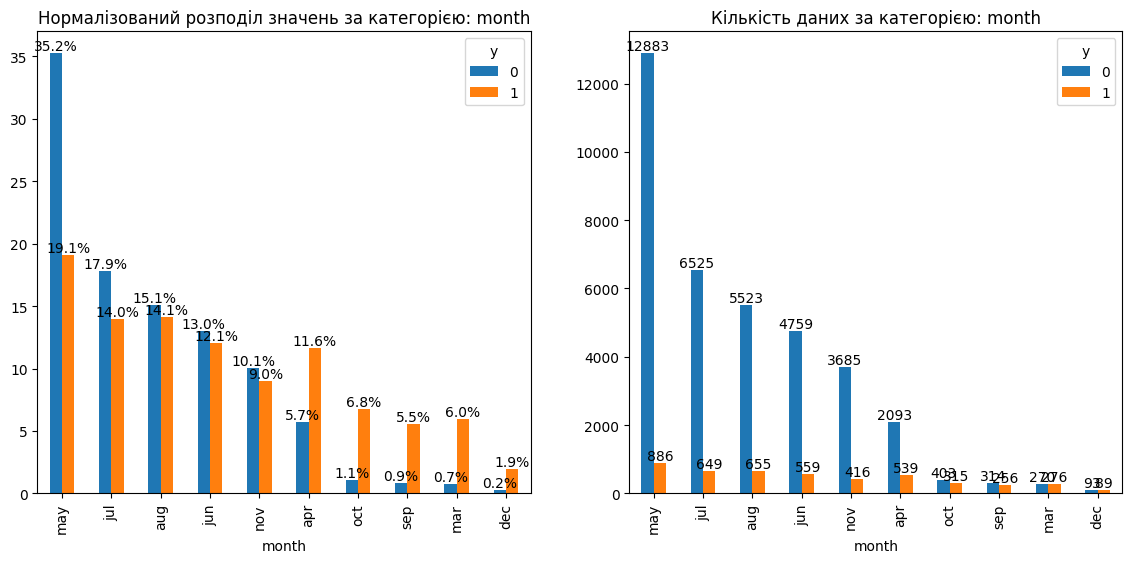

In [ ]:
uctc(df, 'month')

####Висновок до колонки month

відсутні місяці січень і лютий. різна кількість контактів помісячно і суттєва різниця в конверсії по місяцям (весняні і осінні місяці мають значно вищий відсоток y=1


#### Колонка job

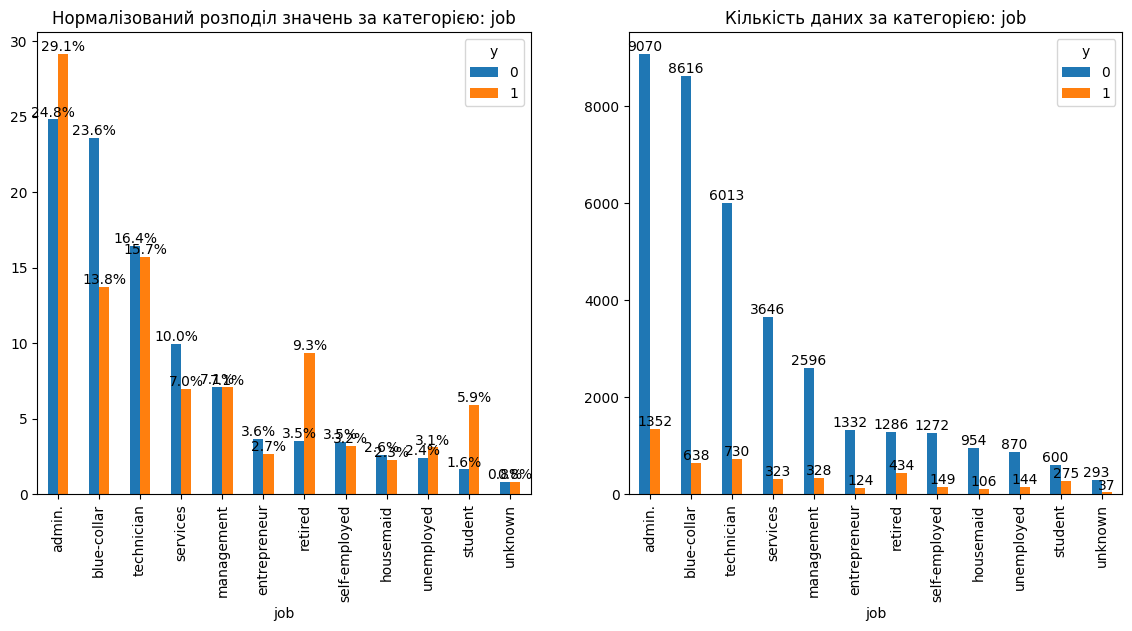

In [ ]:
uctc(df, 'job')

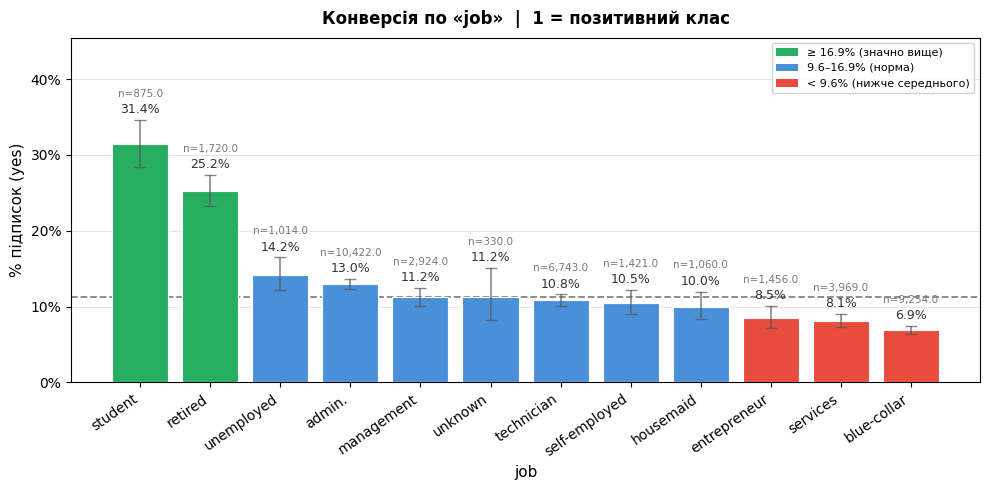

<Axes: title={'center': 'Конверсія по «job»  |  1 = позитивний клас'}, xlabel='job', ylabel='% підписок (yes)'>

In [ ]:
plot_conversion(df, col='job', target_pos=1)

#### Висновок по колонці job
Конверсія значно відрізняється в залежності від роботи і має різний вплив на цільову змінну

####Колонка contact

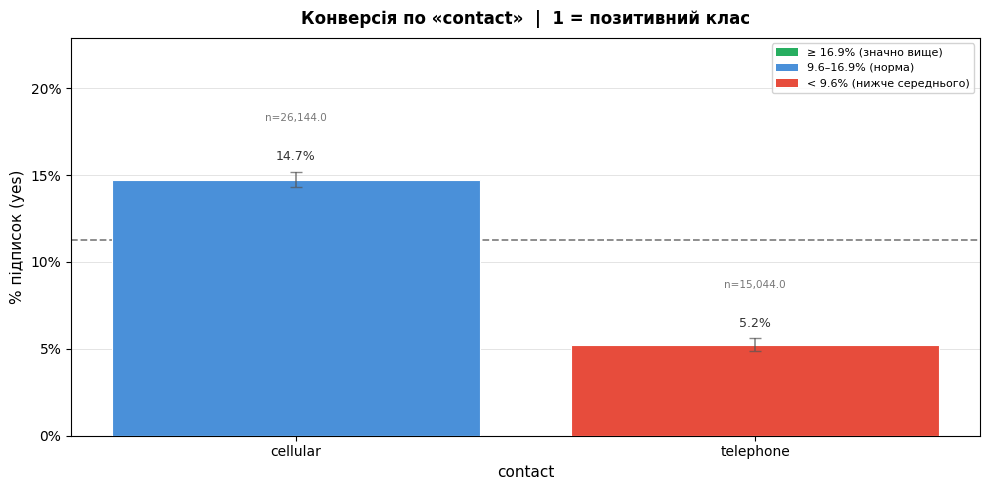

<Axes: title={'center': 'Конверсія по «contact»  |  1 = позитивний клас'}, xlabel='contact', ylabel='% підписок (yes)'>

In [ ]:
plot_conversion(df, col='contact', target_pos=1)

###Висоновок по колонці contact
колонка contact містить 2 значення, можна замінити на 0 і 1. Значна різниця в конверсії, майже в 3 рази.

#### Колонка default

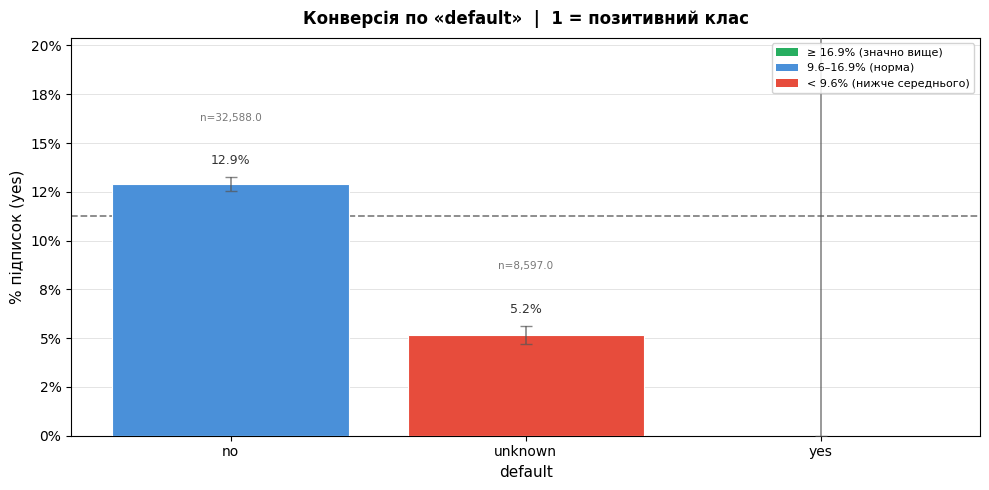

<Axes: title={'center': 'Конверсія по «default»  |  1 = позитивний клас'}, xlabel='default', ylabel='% підписок (yes)'>

In [ ]:
plot_conversion(df, col='default', target_pos=1)

In [ ]:
df[df['default'] == 'yes']

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
21580,48,technician,married,professional.course,yes,no,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
21581,48,technician,married,professional.course,yes,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
24866,31,unemployed,married,high.school,yes,no,no,cellular,nov,tue,...,2,999,1,failure,-0.1,93.200,-42.0,4.153,5195.8,0


####висновок до колонки default

79.1% значень це 'no', решта 'unknown' і 3 записи з 'yes'.
Краще злити 'unknown' і 'yes' в одну категорію

####Колонка education

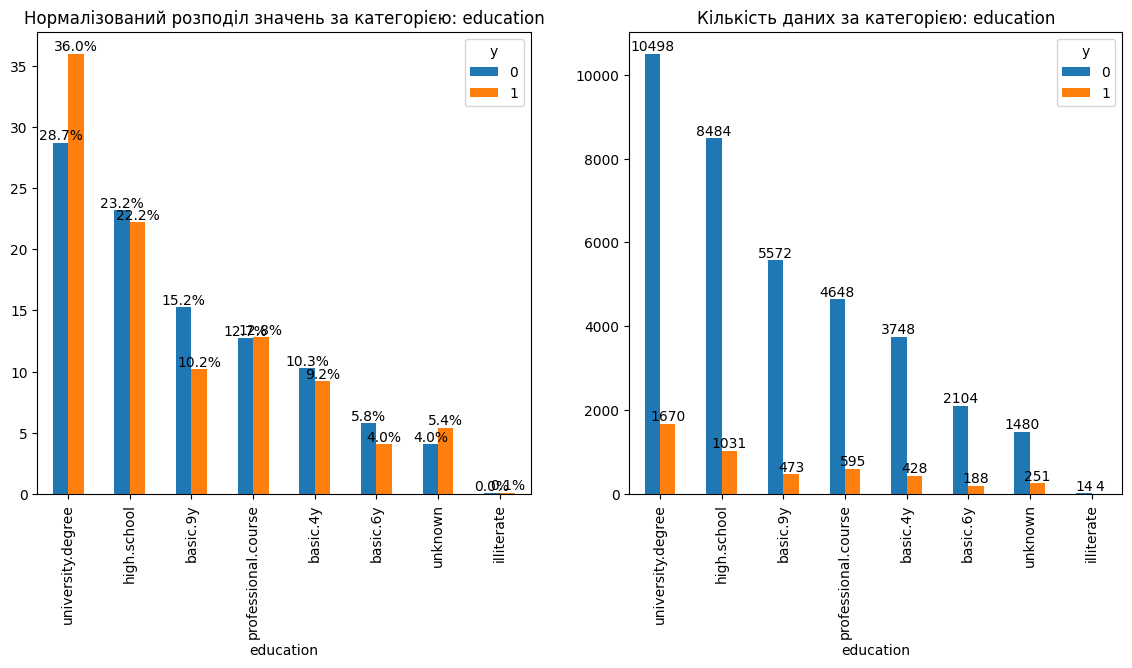

In [ ]:
uctc(df, 'education')

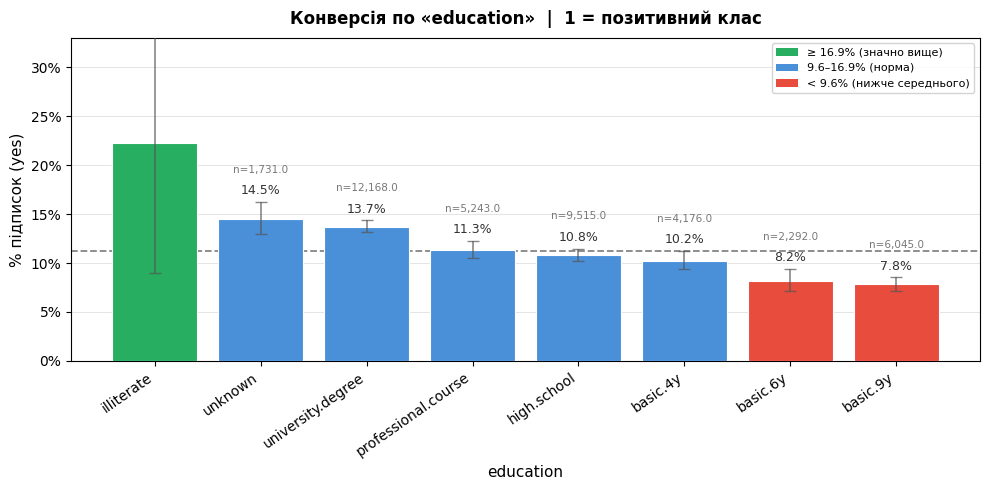

<Axes: title={'center': 'Конверсія по «education»  |  1 = позитивний клас'}, xlabel='education', ylabel='% підписок (yes)'>

In [ ]:
plot_conversion(df, col='education', target_pos=1)

In [ ]:
df[df['education'] == 'illiterate']

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
5393,45,blue-collar,married,illiterate,unknown,no,yes,telephone,may,fri,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
6928,45,blue-collar,married,illiterate,unknown,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0
12383,51,admin.,married,illiterate,unknown,no,no,cellular,jul,mon,...,4,999,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,0
14445,55,blue-collar,married,illiterate,no,yes,no,cellular,jul,tue,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,0
14486,55,blue-collar,married,illiterate,no,no,no,cellular,jul,tue,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,0
16269,60,housemaid,married,illiterate,unknown,yes,no,cellular,jul,tue,...,7,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,0
17739,54,blue-collar,married,illiterate,unknown,yes,yes,cellular,jul,tue,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,0
22402,45,blue-collar,married,illiterate,no,yes,no,cellular,aug,fri,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,0
22642,44,blue-collar,married,illiterate,no,no,no,cellular,aug,fri,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,0
26680,34,self-employed,married,illiterate,no,yes,no,cellular,nov,thu,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,0


#### Висновок до колонки education
Значення illiterate виглядає як аномалія - значень мало (18) а рівень конверсії найвищий.
Можливо варто прибрати або злити цю категорію з найнижчою - basic.4y чи unknown.
також зробити градацію цієї колонки, тобто базову освіту визначити як категорію 1, а high school як 2 і так далі.

####Колонка marital

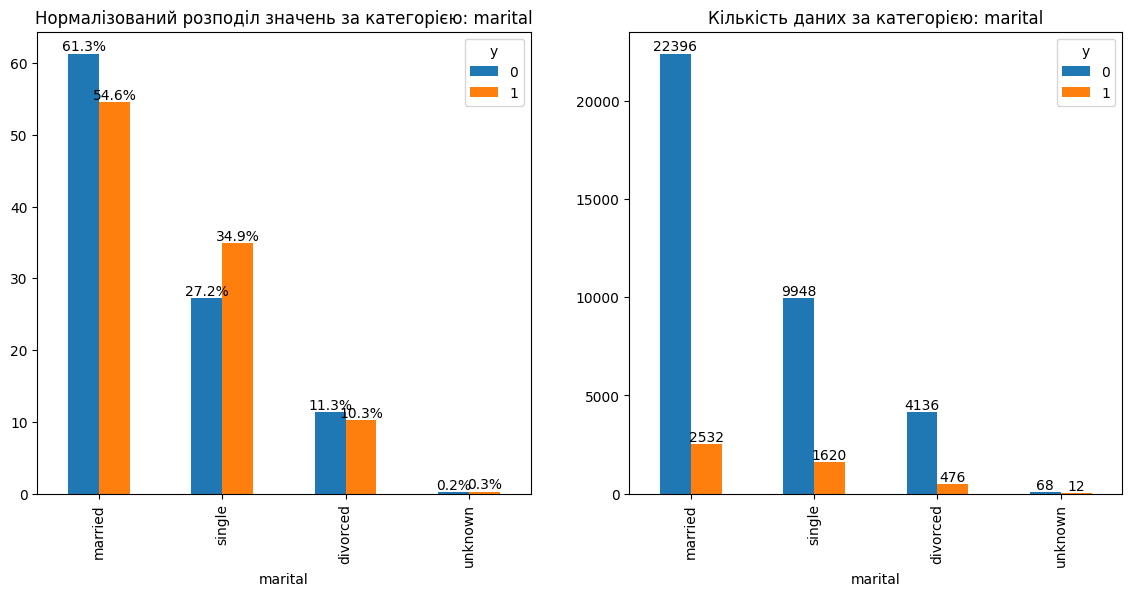

In [ ]:
uctc(df, 'marital')

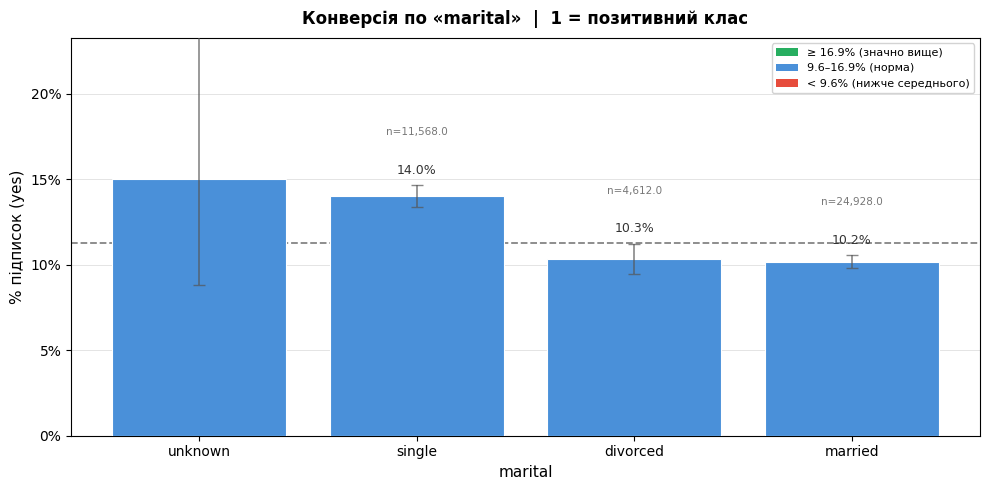

<Axes: title={'center': 'Конверсія по «marital»  |  1 = позитивний клас'}, xlabel='marital', ylabel='% підписок (yes)'>

In [ ]:
plot_conversion(df, col='marital', target_pos=1)

####Висновок до колонки marital

Конвверсія дуже схожа у всіх категоріях колонки, можливо ця колонка додаватиме незначну вагу в модель, unknown значень мало, конверсія там найвища

####Колонка day_of_week

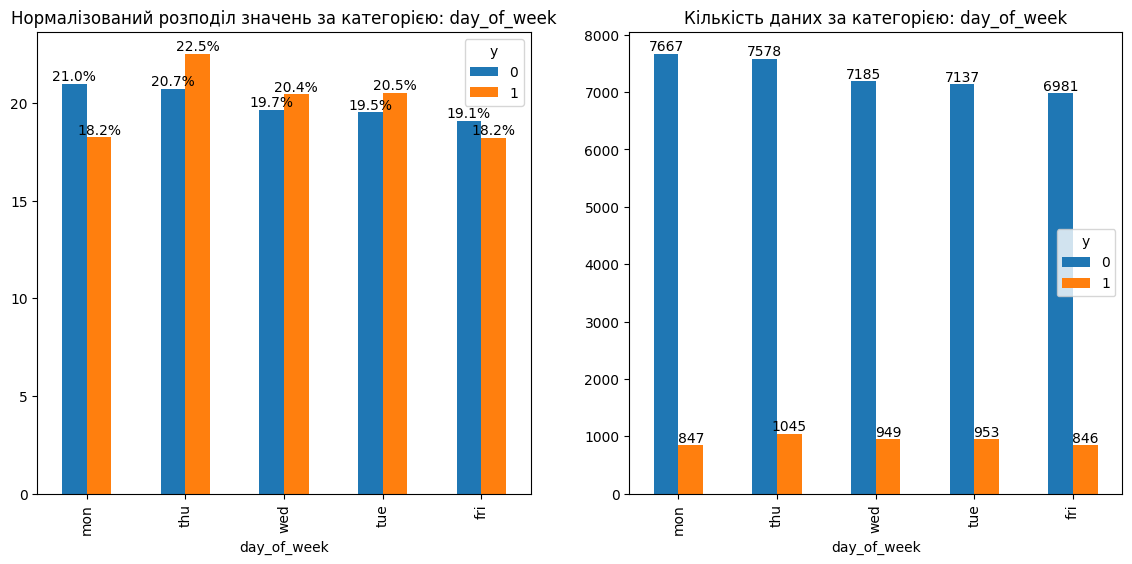

In [ ]:
uctc(df, 'day_of_week')

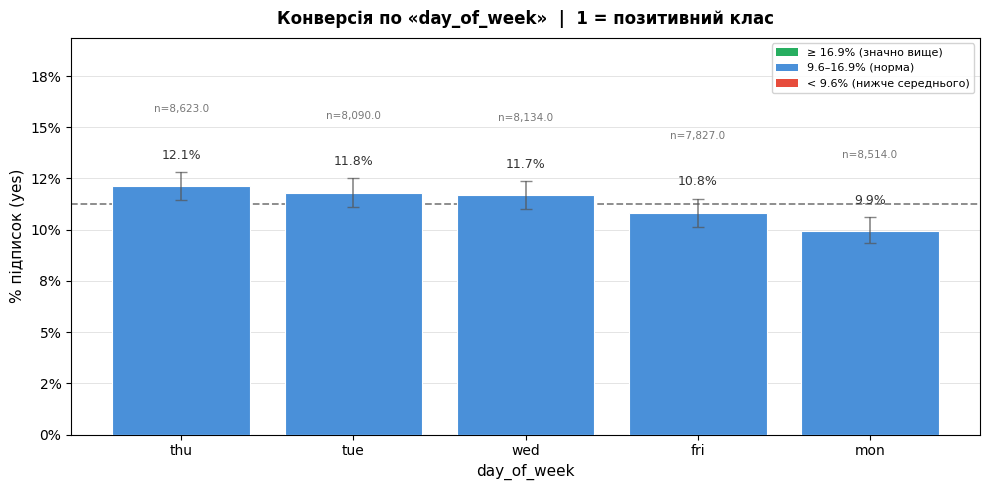

<Axes: title={'center': 'Конверсія по «day_of_week»  |  1 = позитивний клас'}, xlabel='day_of_week', ylabel='% підписок (yes)'>

In [ ]:
plot_conversion(df, col='day_of_week', target_pos=1)

####Висновки до колонки day_of_week
Кількість значень приблизно однакове на кожен день.
Розподіл цільової ознаки також дуже близький по кожному дню, наближається до рівномірного. Не буду включати в модель

#### Колонка housing

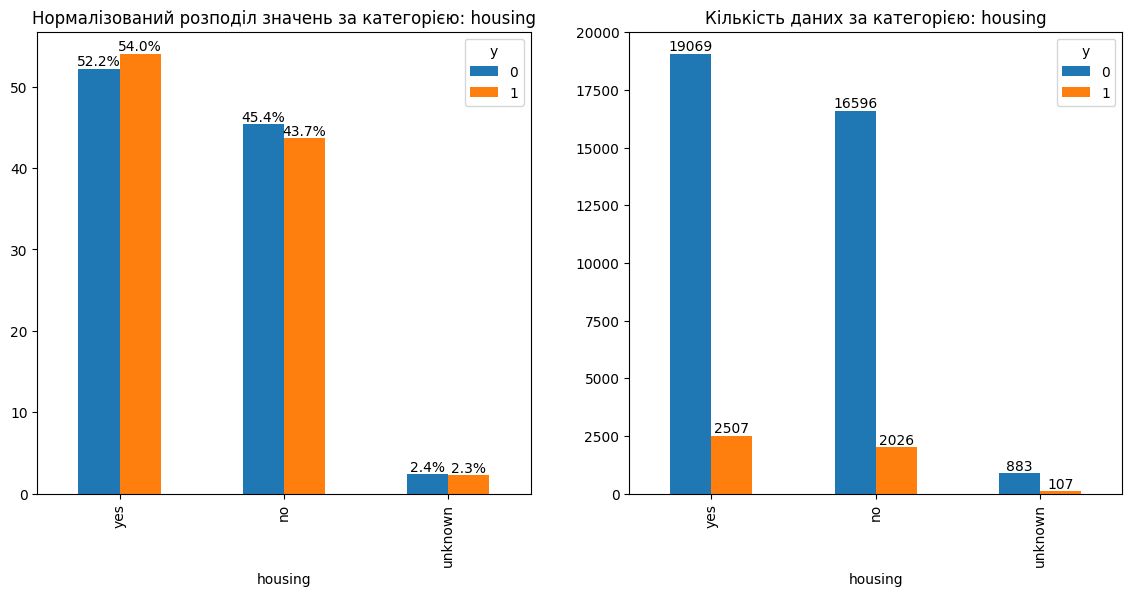

In [ ]:
uctc(df, 'housing')

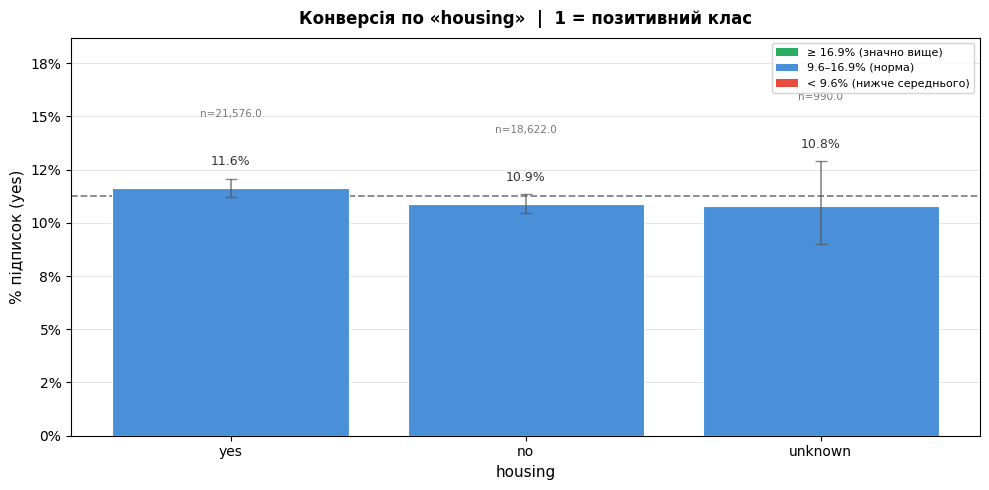

<Axes: title={'center': 'Конверсія по «housing»  |  1 = позитивний клас'}, xlabel='housing', ylabel='% підписок (yes)'>

In [ ]:
plot_conversion(df, col='housing', target_pos=1)

#### Висновки до колонки housing
Розподіл цільової ознаки рівномірний, співвідношення  yes i no неоднакове але близьке, не включатиму у модель

####колонка loan

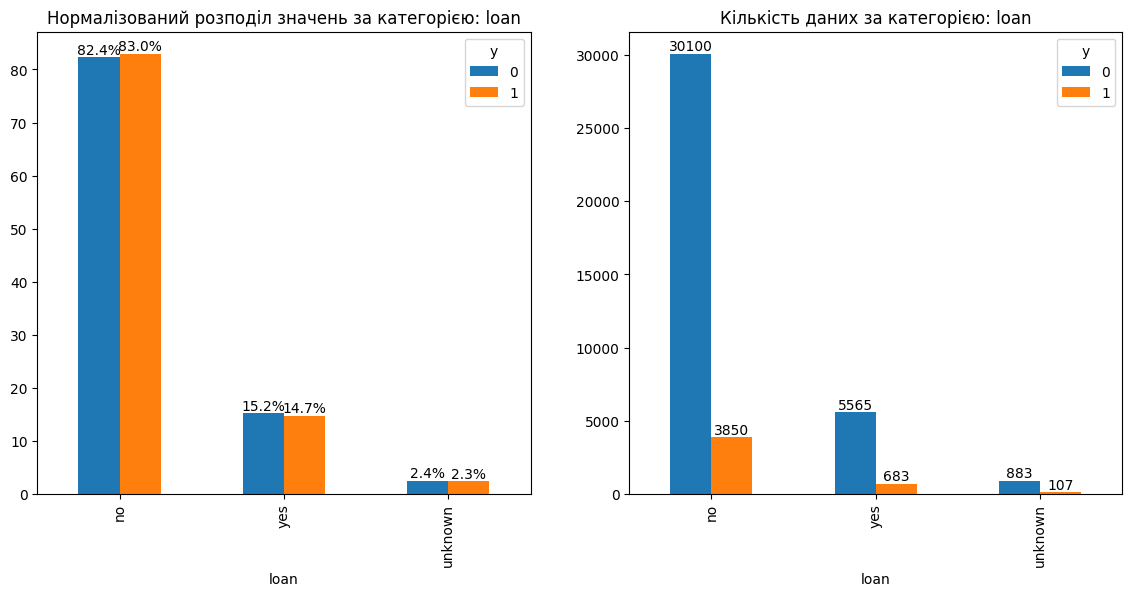

In [ ]:
uctc(df, 'loan')

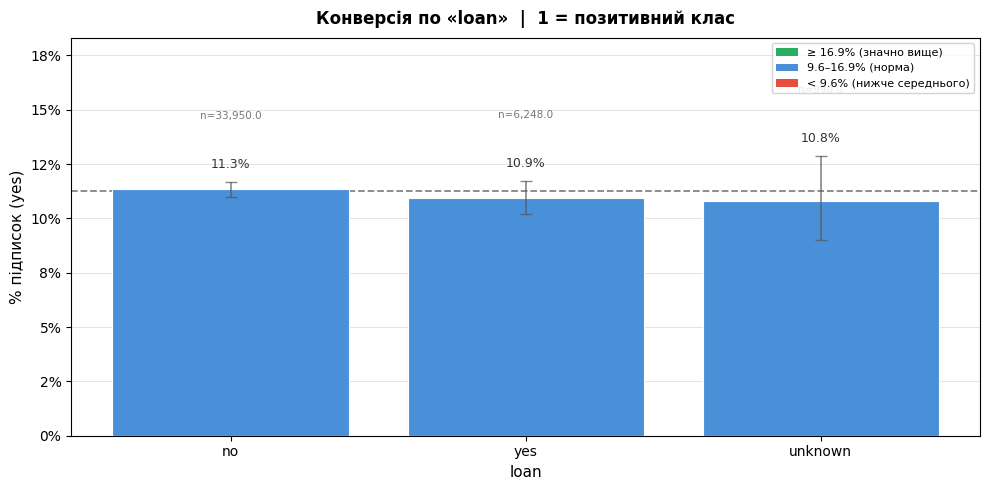

<Axes: title={'center': 'Конверсія по «loan»  |  1 = позитивний клас'}, xlabel='loan', ylabel='% підписок (yes)'>

In [ ]:
plot_conversion(df, col='loan', target_pos=1)

####Висновки до колонки loan
Так як і тут розподіл близький до рівномірного то не бачу сенсу включати в модель

In [ ]:
from preprocessing import preproc_bef_split

In [ ]:
df_prep = preproc_bef_split(pd.read_csv('bank-additional-full.csv', sep=';'))

In [ ]:
df_prep.education

,count
education,
university.degree,12167
high.school,9515
basic.9y,6045
professional.course,5243
basic.4y,4176
basic.6y,2292
unknown,1749
